#Import dependencies

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Added SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

#DATA COLLECTION & PREPROCESSING


In [4]:
heart_data = pd.read_csv('heart_disease_uci.csv')

In [5]:
print("First 5 rows:")
heart_data.head()

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
print("Data type & Non-null counts:")
heart_data.info()

Data type & Non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
print("Missing Values per column:")
heart_data.isnull().sum()

Missing Values per column:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [8]:
print("Descriptive Statistics:")
heart_data.describe()

Descriptive Statistics:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
heart_data['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [10]:
heart_data = heart_data.drop_duplicates()
heart_data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#PLOTTING

Count Plot

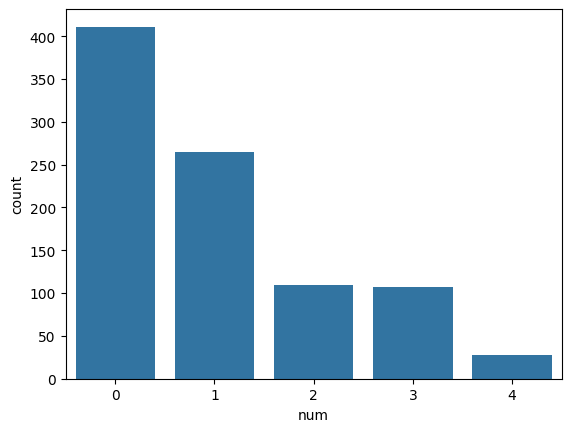

In [11]:
sns.countplot(x='num', data=heart_data)
plt.show()

In [12]:
# Create target variable: 0 = no heart disease, 1 = heart disease
heart_data['target'] = (heart_data['num'] > 0).astype(int)

# Separate features (X) and target (y)
X = heart_data.drop(['target', 'num'], axis=1)
y = heart_data['target']

# Drop columns with a high number of missing values
# Based on heart_data.isnull().sum() output: 'ca' (611), 'thal' (486), 'slope' (309)
X = X.drop(columns=['ca', 'thal', 'slope'])

# One-hot encode categorical features in X
X = pd.get_dummies(X, drop_first=True)

# Impute remaining numerical missing values with the mean
# Identify numerical columns that might still have NaNs (e.g., trestbps, chol, fbs_True, restecg_True, thalch, exang_True, oldpeak)
numerical_cols_with_nan = X.select_dtypes(include=np.number).columns[X.select_dtypes(include=np.number).isnull().any()].tolist()

if numerical_cols_with_nan:
    imputer = SimpleImputer(strategy='mean')
    X[numerical_cols_with_nan] = imputer.fit_transform(X[numerical_cols_with_nan])

print("Target variable created, features processed (high NaN columns dropped, remaining NaNs imputed), and one-hot encoded successfully.")

Target variable created, features processed (high NaN columns dropped, remaining NaNs imputed), and one-hot encoded successfully.


#CHECK TARGET COLUMN

In [13]:
heart_data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


Count Target Values

In [14]:
heart_data['target'].value_counts()

,count
target,
1,509
0,411


Heatmap

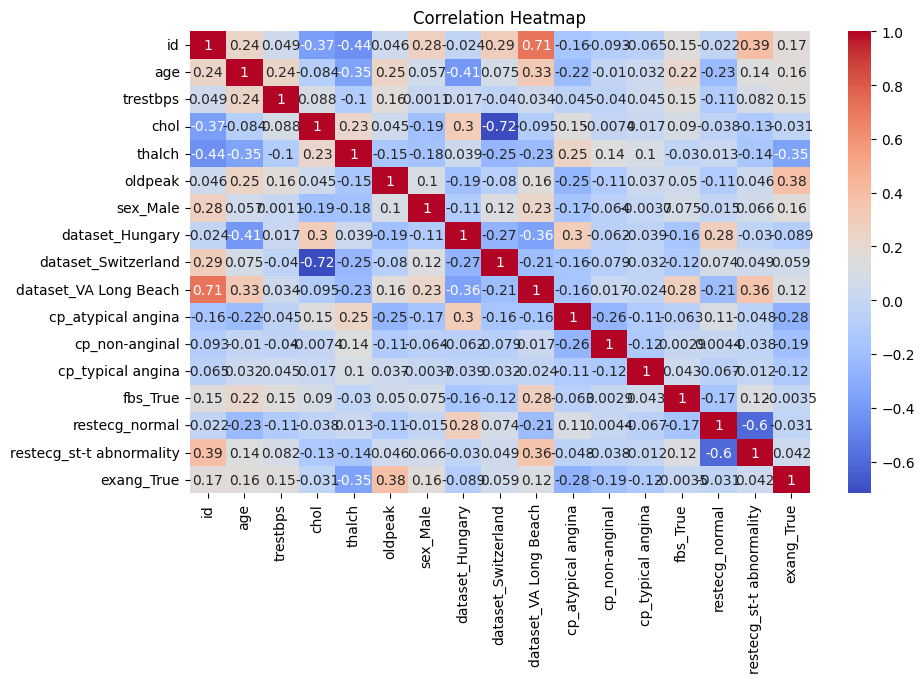

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Histplot

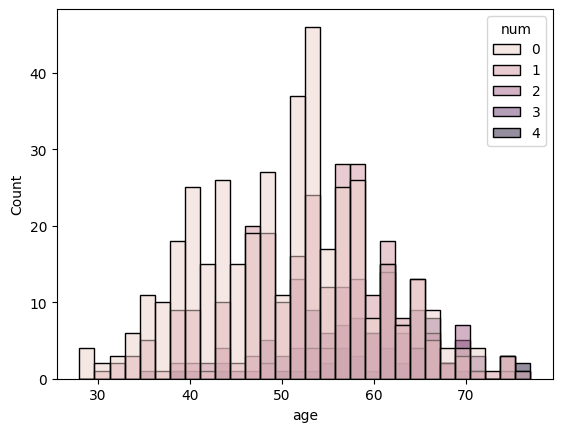

In [16]:
sns.histplot(data=heart_data, x='age', hue='num', bins=30)
plt.show()

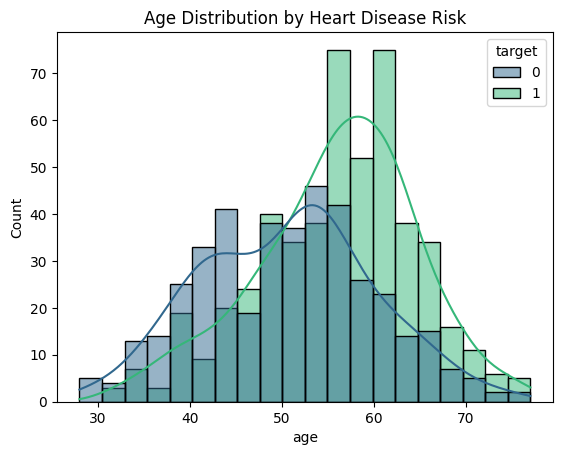

In [17]:
sns.histplot(data=heart_data, x='age', hue='target', kde=True, bins=20, palette='viridis')
plt.title('Age Distribution by Heart Disease Risk')
plt.show()

#TRAINNING

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Scaling and Alignment

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training: Logistic Regression

In [21]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

#Model Training: Decision Tree

In [22]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

Predictions

In [23]:
lr_model_preds = lr_model.predict(X_test)

In [24]:
dt_model_preds = dt_model.predict(X_test)

Accuracy

In [25]:
print("Logistic Redression Accuracy:", accuracy_score(y_test, lr_model_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_model_preds))

Logistic Redression Accuracy: 0.8260869565217391
Decision Tree Accuracy: 0.7391304347826086


#Confusin Matrix

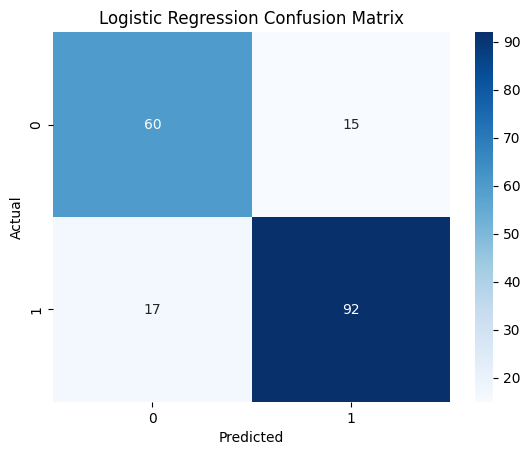

In [26]:
cm = confusion_matrix(y_test, lr_model_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC Curve

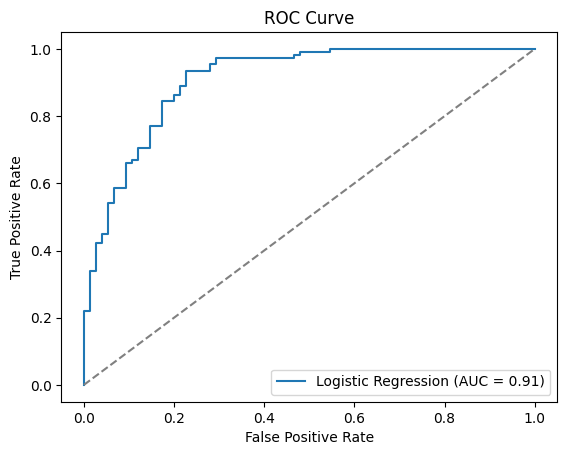

In [27]:
lr_probs = lr_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
auc = roc_auc_score(y_test, lr_probs)

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend()
plt.show()

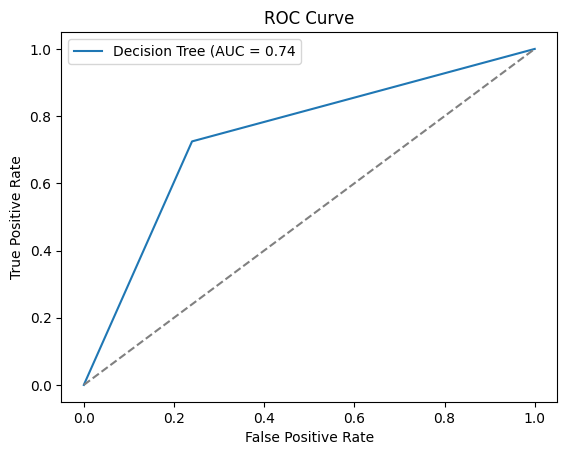

In [28]:
dt_probs = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, dt_probs)
auc = roc_auc_score(y_test, dt_probs)

plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend()
plt.show()

#Feature Importance

Logistic Regression model


In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr_model.coef_[0]}).sort_values(by= "Importance", ascending=False)

print(importance)

                     Feature  Importance
0                         id    1.830936
5                    oldpeak    0.809347
6                   sex_Male    0.658183
16                exang_True    0.461944
13                  fbs_True    0.142793
1                        age    0.115393
3                       chol    0.104021
2                   trestbps    0.036837
15  restecg_st-t abnormality   -0.045742
8        dataset_Switzerland   -0.096011
14            restecg_normal   -0.107961
4                     thalch   -0.165352
12         cp_typical angina   -0.354218
11            cp_non-anginal   -0.504306
10        cp_atypical angina   -0.737305
7            dataset_Hungary   -0.988319
9      dataset_VA Long Beach   -1.711214


Decision Tree Importance

In [30]:
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_}).sort_values(by= "Importance", ascending=False)

print(dt_importance)

                     Feature  Importance
0                         id    0.548173
5                    oldpeak    0.122211
4                     thalch    0.099926
3                       chol    0.067159
2                   trestbps    0.041882
6                   sex_Male    0.028726
1                        age    0.027338
16                exang_True    0.018095
11            cp_non-anginal    0.015808
12         cp_typical angina    0.010617
13                  fbs_True    0.007607
10        cp_atypical angina    0.006980
15  restecg_st-t abnormality    0.005476
8        dataset_Switzerland    0.000000
7            dataset_Hungary    0.000000
9      dataset_VA Long Beach    0.000000
14            restecg_normal    0.000000


#Probabilty of Heart Disease According to features

In [31]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Example usage: Define sample values for the variables
# You can replace these with actual data points or user inputs
age = 80
chest_pain = 1  # Assuming a numerical representation for chest pain, e.g., 0 for no pain, 1 for typical, etc.
chol = 218
thalach = 150

risk_score = (0.03 * age) + (0.8 * chest_pain) + (0.02 * chol) - (0.05 * thalach)

probability = sigmoid(risk_score)

if probability > 0.5:
    print(f"Heart Disease (Probability: {probability:.2f})")
else:
    print(f"No Heart Disease (Probability: {probability:.2f})")

Heart Disease (Probability: 0.51)


In [32]:
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider, BoundedFloatText
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# Ensure the scaler is available and X is the original preprocessed DataFrame for column names
# scaler and X are available from previous cells

def predict_heart_disease(age, trestbps, chol, thalch, oldpeak, sex, cp_type, fbs, exang):
    # Create a DataFrame for a single input, matching the structure of X before scaling
    input_data = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

    # Populate the input_data DataFrame with user values
    input_data['age'] = age
    input_data['trestbps'] = trestbps
    input_data['chol'] = chol
    input_data['thalch'] = thalch
    input_data['oldpeak'] = oldpeak

    # Handle binary and one-hot encoded categorical features
    input_data['sex_Male'] = 1 if sex == 'Male' else 0
    if cp_type == 'Atypical Angina':
        input_data['cp_atypical angina'] = 1
    elif cp_type == 'Non-Anginal Pain':
        input_data['cp_non-anginal'] = 1
    elif cp_type == 'Typical Angina':
        input_data['cp_typical angina'] = 1
    # 'asymptomatic' is the reference category (all cp_type columns are 0)

    input_data['fbs_True'] = 1 if fbs == 'True' else 0
    input_data['exang_True'] = 1 if exang == 'True' else 0

    # Scale the input data using the fitted StandardScaler
    # It's crucial that the order of columns and scaling is consistent
    scaled_input = scaler.transform(input_data)

    # Predict probability using the trained Logistic Regression model
    probability = lr_model.predict_proba(scaled_input)[:, 1][0]
    prediction = "Heart Disease" if probability > 0.5 else "No Heart Disease"

    display(HTML(f"<h3>Prediction: <span style='color:{'red' if prediction == 'Heart Disease' else 'green'};'>{prediction}</span></h3>" +
                 f"<p>Probability of Heart Disease: <b>{probability:.2f}</b></p>"))


# Define widgets for interactive input
interact(
    predict_heart_disease,
    age=IntSlider(min=28, max=77, step=1, value=50, description='Age'),
    trestbps=IntSlider(min=90, max=200, step=1, value=120, description='Resting BP'),
    chol=IntSlider(min=100, max=600, step=1, value=200, description='Cholesterol'),
    thalch=IntSlider(min=70, max=202, step=1, value=150, description='Max HR'),
    oldpeak=FloatSlider(min=-2.6, max=6.2, step=0.1, value=1.0, description='ST Depression'),
    sex=Dropdown(options=['Male', 'Female'], value='Male', description='Sex'),
    cp_type=Dropdown(options=['Typical Angina', 'Atypical Angina', 'Non-Anginal Pain', 'Asymptomatic'], value='Asymptomatic', description='Chest Pain Type'),
    fbs=Dropdown(options=['True', 'False'], value='False', description='Fasting Blood Sugar > 120 mg/dl'),
    exang=Dropdown(options=['True', 'False'], value='False', description='Exercise Induced Angina')
);


interactive(children=(IntSlider(value=50, description='Age', max=77, min=28), IntSlider(value=120, description…

### Interactive Heart Disease Prediction UI (using Gradio)

Below is a Gradio interface that allows you to interact with the trained Logistic Regression model. Adjust the inputs and click 'Predict' to see the model's output.

In [33]:
import gradio as gr

# Ensure the scaler, X, and lr_model are available from previous cells

def predict_heart_disease_gradio(age, trestbps, chol, thalch, oldpeak, sex, cp_type, fbs, exang):
    # Create a DataFrame for a single input, matching the structure of X before scaling
    input_data = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

    # Populate the input_data DataFrame with user values
    input_data['age'] = age
    input_data['trestbps'] = trestbps
    input_data['chol'] = chol
    input_data['thalch'] = thalch
    input_data['oldpeak'] = oldpeak

    # Handle binary and one-hot encoded categorical features
    input_data['sex_Male'] = 1 if sex == 'Male' else 0
    if cp_type == 'Atypical Angina':
        input_data['cp_atypical angina'] = 1
    elif cp_type == 'Non-Anginal Pain':
        input_data['cp_non-anginal'] = 1
    elif cp_type == 'Typical Angina':
        input_data['cp_typical angina'] = 1
    # 'asymptomatic' is the reference category (all cp_type columns are 0)

    input_data['fbs_True'] = 1 if fbs == 'True' else 0
    input_data['exang_True'] = 1 if exang == 'True' else 0

    # Scale the input data using the fitted StandardScaler
    # It's crucial that the order of columns and scaling is consistent
    scaled_input = scaler.transform(input_data)

    # Predict probability using the trained Logistic Regression model
    probability = lr_model.predict_proba(scaled_input)[:, 1][0]
    prediction = "Heart Disease" if probability > 0.5 else "No Heart Disease"

    color = 'red' if prediction == 'Heart Disease' else 'green'
    return f"<h3>Prediction: <span style='color:{color};'>{prediction}</span></h3><p>Probability of Heart Disease: <b>{probability:.2f}</b></p>"


# Define Gradio interface components
inputs = [
    gr.Slider(minimum=28, maximum=77, step=1, value=50, label='Age'),
    gr.Slider(minimum=90, maximum=200, step=1, value=120, label='Resting Blood Pressure (trestbps)'),
    gr.Slider(minimum=100, maximum=600, step=1, value=200, label='Cholesterol (chol)'),
    gr.Slider(minimum=70, maximum=202, step=1, value=150, label='Max Heart Rate (thalch)'),
    gr.Slider(minimum=-2.6, maximum=6.2, step=0.1, value=1.0, label='ST Depression (oldpeak)'),
    gr.Dropdown(choices=['Male', 'Female'], value='Male', label='Sex'),
    gr.Dropdown(choices=['Typical Angina', 'Atypical Angina', 'Non-Anginal Pain', 'Asymptomatic'], value='Asymptomatic', label='Chest Pain Type (cp)'),
    gr.Dropdown(choices=['True', 'False'], value='False', label='Fasting Blood Sugar > 120 mg/dl (fbs)'),
    gr.Dropdown(choices=['True', 'False'], value='False', label='Exercise Induced Angina (exang)')
]

outputs = gr.HTML(label='Prediction Result')

# Create and launch the Gradio interface
interface = gr.Interface(
    fn=predict_heart_disease_gradio,
    inputs=inputs,
    outputs=outputs,
    title="Heart Disease Prediction",
    description="Enter patient characteristics to predict the likelihood of heart disease using a Logistic Regression model."
)

interface.launch(inline=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b3424a56d03452d40.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
